In [5]:
from google.colab import files
uploaded=files.upload()

Saving Amex_Proj_data.txt to Amex_Proj_data.txt


In [6]:
#Phase 1--> PROJECT INITIALIZATION(Setup)

#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Load datset:
df=pd.read_csv("Amex_Proj_data.txt")

#Quick Overview
df.shape
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             51000 non-null  object 
 1   Age                     50487 non-null  float64
 2   Gender                  51000 non-null  object 
 3   Region                  51000 non-null  object 
 4   Income_Range            51000 non-null  object 
 5   Account_Tenure_Years    51000 non-null  int64  
 6   Transaction_ID          51000 non-null  object 
 7   Transaction_Date        51000 non-null  object 
 8   Transaction_Amount      50485 non-null  float64
 9   Merchant_Category       51000 non-null  object 
 10  Payment_Status          51000 non-null  object 
 11  Payment_Method          51000 non-null  object 
 12  Credit_Limit            50489 non-null  float64
 13  Current_Balance         50488 non-null  float64
 14  Reward_Points_Earned    51000 non-null

,Age,Account_Tenure_Years,Transaction_Amount,Credit_Limit,Current_Balance,Reward_Points_Earned,Reward_Points_Redeemed
count,50487.000000,51000.000000,50485.000000,50489.000000,50488.000000,51000.000000,51000.000000
mean,43.501733,7.486941,2665.237853,52538.936481,39957.691709,2510.437039,2002.271118
std,14.989474,4.026991,4607.530029,27370.983188,23040.741002,1444.300281,1152.980557
min,18.000000,1.000000,100.000000,5000.000000,2.000000,0.000000,0.000000
25%,31.000000,4.000000,1318.000000,28732.000000,20060.000000,1265.000000,1009.000000
50%,43.000000,7.000000,2547.000000,52597.000000,39926.000000,2509.000000,2008.000000
75%,56.000000,11.000000,3779.000000,76201.000000,59789.000000,3776.000000,2998.000000
max,69.000000,14.000000,249050.000000,99996.000000,79997.000000,4999.000000,3999.000000


In [7]:
#Phase 2--> DATA CLEANING(Objective: Fix missing values,duplicates and incosistecies)

#Step1:Identify missing values:
df.isnull().sum()

#Handle Missing Values
#Fill Age with overall median
df['Age'].fillna(df['Age'].median(),inplace=True)
#Fill Transaction_Amount with median of same merchant category
df['Transaction_Amount']=df.groupby('Merchant_Category')['Transaction_Amount'].transform(lambda x: x.fillna(x.median()))
#Fill Credit_Limit with median based on income range
df['Credit_Limit']=df.groupby('Income_Range')['Credit_Limit'].transform(lambda x: x.fillna(x.median()))
#Fill Current_Balance with 0 (assuming some account had no balance)
df['Current_Balance'].fillna(0,inplace=True)

df.isnull().sum()





/tmp/ipython-input-1518570121.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)
/tmp/ipython-input-1518570121.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,0
Customer_ID,0
Age,0
Gender,0
Region,0
Income_Range,0
Account_Tenure_Years,0
Transaction_ID,0
Transaction_Date,0
Transaction_Amount,0
Merchant_Category,0


In [8]:
#Step2: Handle Duplicates

df.duplicated().sum()

np.int64(960)

In [9]:
#Step3: Fix Incosistent Text cases

df['Region']=df['Region'].str.title()
df['Merchant_Category']=df['Merchant_Category'].str.title()
df['Customer_ID']=df['Customer_ID'].str.upper()
df['Gender']=df['Gender'].str.title()
df['Income_Range']=df['Income_Range'].str.title()
df['Transaction_ID']=df['Transaction_ID'].str.upper()
df['Payment_Status']=df['Payment_Status'].str.title()
df['Payment_Method']=df['Payment_Method'].str.title()
df['Risk_Flag']=df['Risk_Flag'].str.title()

df.head()



,Customer_ID,Age,Gender,Region,Income_Range,Account_Tenure_Years,Transaction_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Status,Payment_Method,Credit_Limit,Current_Balance,Reward_Points_Earned,Reward_Points_Redeemed,Risk_Flag
0,CUST100000,56.0,Male,Ohio,Medium,14,TXN500000,2022-11-13,1816.0,Groceries,Paid,Credit Card,80282.0,44814.0,2320,1216,Low
1,CUST100001,69.0,Female,New York,Low,8,TXN500001,2023-07-15,3289.0,Retail,Paid,Debit Card,93940.0,40598.0,964,432,Low
2,CUST100002,46.0,Female,Florida,Low,14,TXN500002,2023-03-18,715.0,Utilities,Late,Debit Card,52780.0,65486.0,2491,3484,Low
3,CUST100003,32.0,Male,Texas,Low,14,TXN500003,2022-09-19,3145.0,Retail,Paid,Credit Card,13654.0,19302.0,507,2118,Low
4,CUST100004,60.0,Male,Arizona,Low,6,TXN500004,2022-03-13,630.0,Online Shopping,Late,Upi,26901.0,4567.0,4146,2798,Low


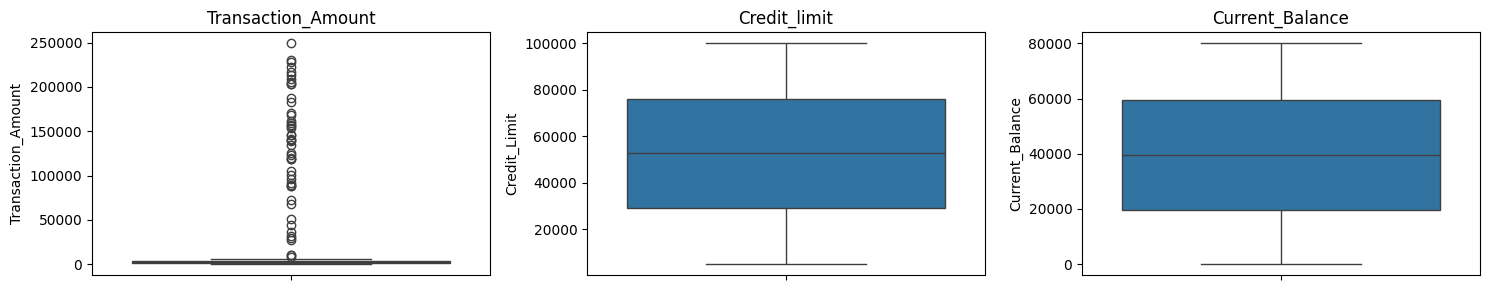

In [10]:
#Step 4: Outliers detection & treatment

#1. Visualize with Boxplots

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
sns.boxplot(df['Transaction_Amount'])
plt.title('Transaction_Amount')

plt.subplot(1,3,2)
sns.boxplot(df['Credit_Limit'])
plt.title('Credit_limit')

plt.subplot(1,3,3)
sns.boxplot(df['Current_Balance'])
plt.title('Current_Balance')

plt.tight_layout()
plt.show()











Transaction_Amount:
 IQR Range --> [-2320.00,7416.00]
 outliers before capping:48
 outliers after capping:0

Credit_Limit:
 IQR Range --> [-41486.38,146466.62]
 outliers before capping:0
 outliers after capping:0

Current_Balance:
 IQR Range --> [-40779.88,119849.12]
 outliers before capping:0
 outliers after capping:0



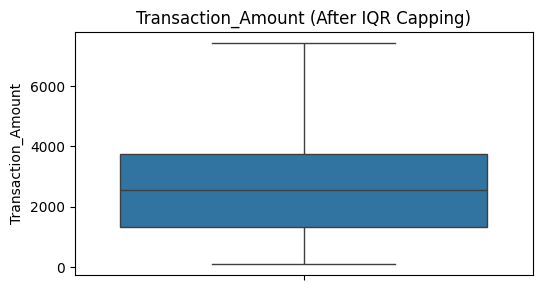

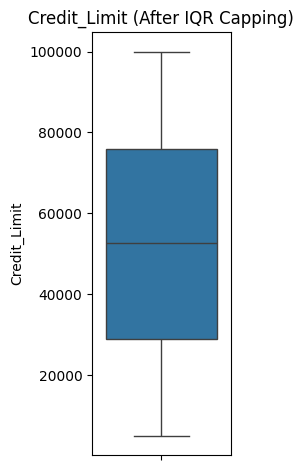

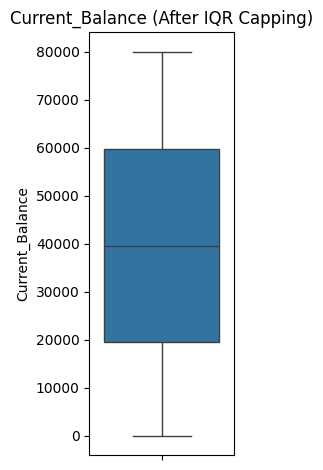

In [11]:
#2. Statastical Detection Using IQR Method
#IQR Outlier Detection & Capping Fucntion

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def cap_outliers_iqr(df,columns):
  for col in columns:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    before=((df[col]<lower_bound)|(df[col]>upper_bound)).sum()

    df[col]=np.where(df[col]>upper_bound,upper_bound,
    np.where(df[col]<lower_bound,lower_bound,df[col]))

    after=((df[col]<lower_bound)|(df[col]>upper_bound)).sum()

    print(f"{col}:")
    print(f" IQR Range --> [{lower_bound:.2f},{upper_bound:.2f}]")
    print(f" outliers before capping:{before}")
    print(f" outliers after capping:{after}\n")

cols_to_cap=['Transaction_Amount','Credit_Limit','Current_Balance']

cap_outliers_iqr(df,cols_to_cap)

plt.figure(figsize=(15,3))
for i, col in enumerate(cols_to_cap,1):
      plt.subplot(1,3,i)
      sns.boxplot(df[col])
      plt.title(f"{col} (After IQR Capping)")
      plt.tight_layout()
      plt.show()



In [12]:
#Step 5: Data Type Correction
print("before:",df.dtypes)

#Conversion Part

#Converting Transaction_date
df['Transaction_Date']=pd.to_datetime(df['Transaction_Date'],errors='coerce')

#Converting Categorial Names
cat_cols=['Gender','Region','Income_Range','Merchant_Category','Payment_Status','Payment_Method','Risk_Flag']
for col in cat_cols:
  df[col]=df[col].astype('category')

#Converting Age to int
if(df['Age']%1==0).all():
  df['Age']=df['Age'].astype('int64')

print("After:",df.dtypes)

before: Customer_ID                object
Age                       float64
Gender                     object
Region                     object
Income_Range               object
Account_Tenure_Years        int64
Transaction_ID             object
Transaction_Date           object
Transaction_Amount        float64
Merchant_Category          object
Payment_Status             object
Payment_Method             object
Credit_Limit              float64
Current_Balance           float64
Reward_Points_Earned        int64
Reward_Points_Redeemed      int64
Risk_Flag                  object
dtype: object
After: Customer_ID                       object
Age                                int64
Gender                          category
Region                          category
Income_Range                    category
Account_Tenure_Years               int64
Transaction_ID                    object
Transaction_Date          datetime64[ns]
Transaction_Amount               float64
Merchant_Category       

In [13]:
#Phase 3 --> FEATURE ENGINEERING

#Step 1: Credit Utilization%
df['Credit_Utilization_%']=((df['Current_Balance']/df['Credit_Limit'])*100).clip(upper=100).round(1)

#Step 2: Late Payment Flag:(1--> "Late",0--> "Else")
df['Late_Payment_Flag']=np.where(df['Payment_Status'].str.lower()=='late',1,0)

#Step 3: Transaction Month & Year
df['Transaction_Date']=pd.to_datetime(df['Transaction_Date'],errors='coerce')
df['Transaction_Month']=df['Transaction_Date'].dt.month
df['Transaction_Year']=df['Transaction_Date'].dt.year

#Step 4: Reward Utilization%
df['Reward_Utilization_%']=((df['Reward_Points_Redeemed']/df['Reward_Points_Earned']+1)*100).clip(upper=100).round(1)

#Step 5: Spending Category
df['Spending_Category']=pd.qcut(df['Transaction_Amount'],3,labels=['Low','Medium','High'])


#Quick Check
df[['Credit_Utilization_%','Late_Payment_Flag','Transaction_Month','Transaction_Year','Reward_Utilization_%','Spending_Category']].head()



,Credit_Utilization_%,Late_Payment_Flag,Transaction_Month,Transaction_Year,Reward_Utilization_%,Spending_Category
0,55.8,0,11,2022,100.0,Medium
1,43.2,0,7,2023,100.0,Medium
2,100.0,1,3,2023,100.0,Low
3,100.0,0,9,2022,100.0,Medium
4,17.0,1,3,2022,100.0,Low


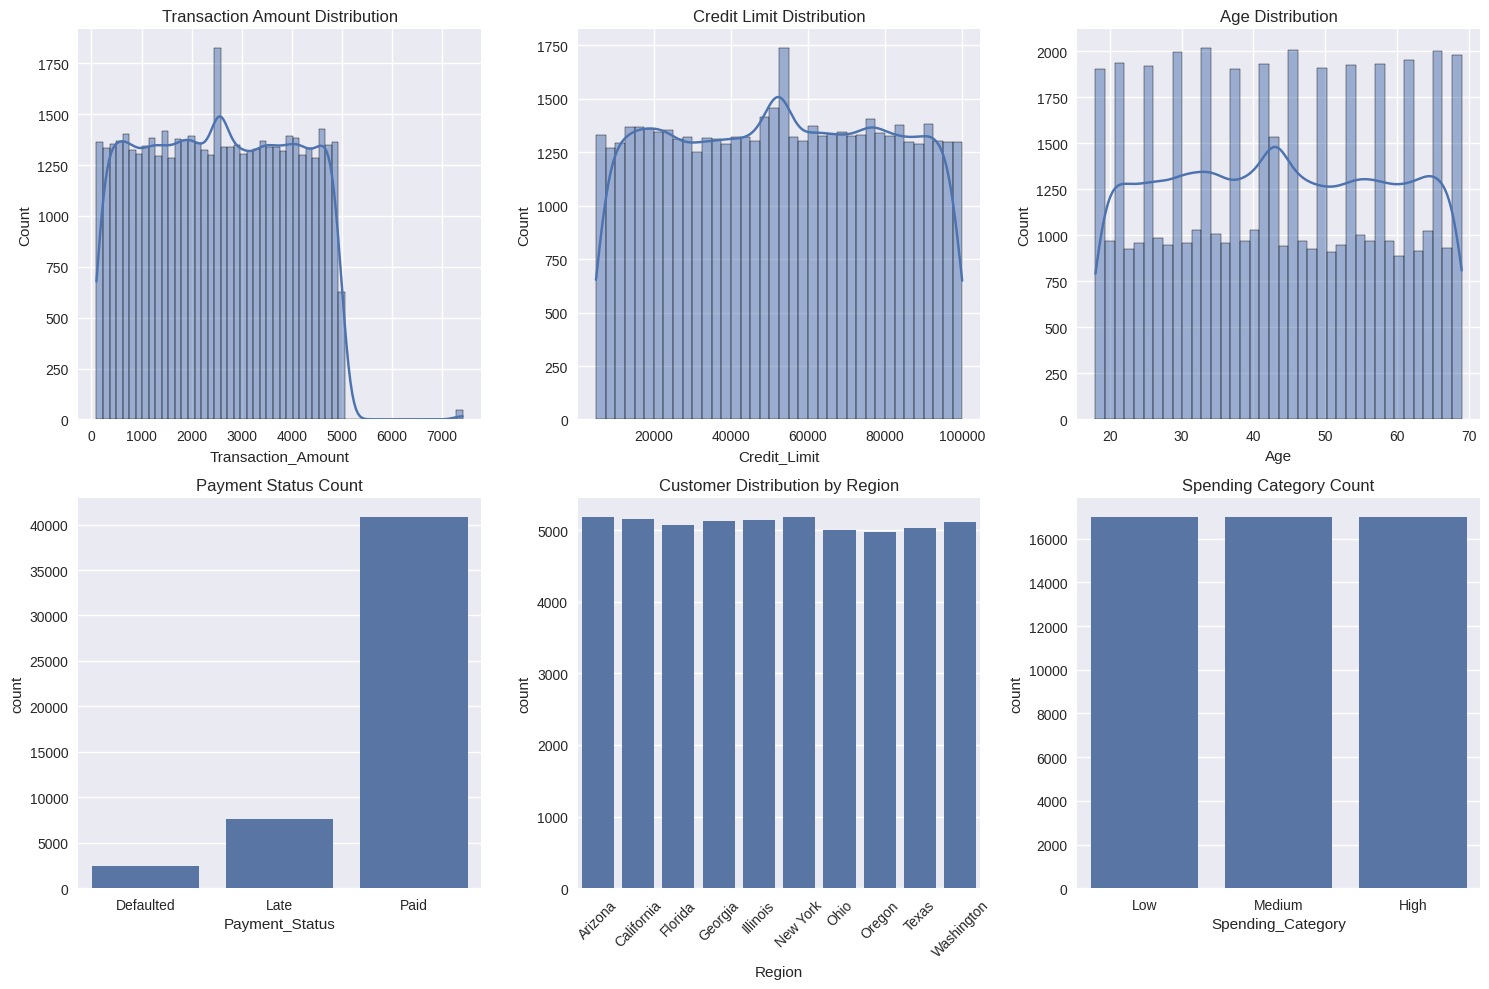

In [14]:
#Phase 4 --> EXPLORATORY DATA ANALYSIS (EDA)

#Step 1: Univariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
plt.figure(figsize=(15,10))

#transaction amount distribution
plt.subplot(2,3,1)
sns.histplot(df['Transaction_Amount'],kde=True)
plt.title('Transaction Amount Distribution')

#credit limit distribution
plt.subplot(2,3,2)
sns.histplot(df['Credit_Limit'],kde=True)
plt.title("Credit Limit Distribution")

#Age distribution
plt.subplot(2,3,3)
sns.histplot(df['Age'],kde=True)
plt.title("Age Distribution")

#Payment Status Count
plt.subplot(2,3,4)
sns.countplot(x='Payment_Status',data=df)
plt.title("Payment Status Count")

#Region Count
plt.subplot(2,3,5)
sns.countplot(x='Region',data=df)
plt.title("Customer Distribution by Region")
plt.xticks(rotation=45)

#Spending Category
plt.subplot(2,3,6)
sns.countplot(x='Spending_Category',data=df)
plt.title("Spending Category Count")

plt.tight_layout()
plt.show()



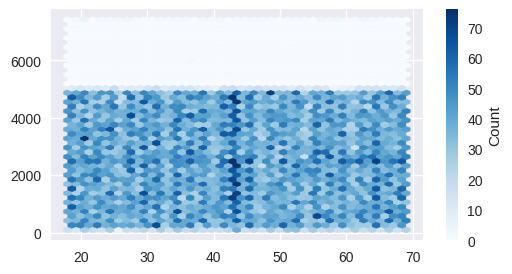

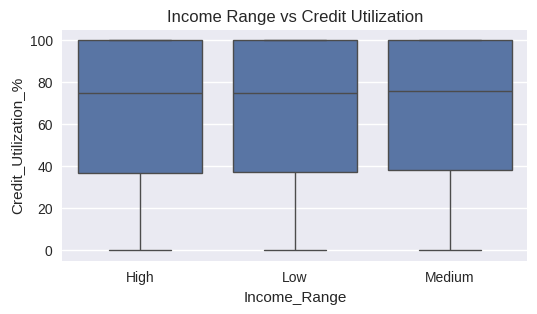

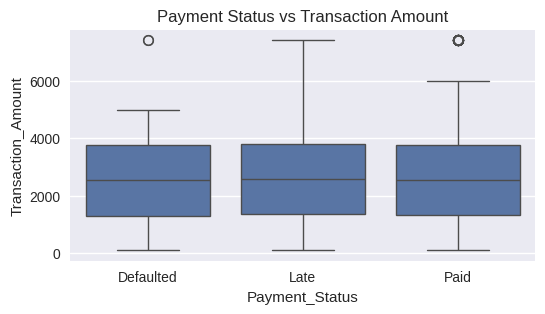

/tmp/ipython-input-2228132284.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_spend=df.groupby('Region')['Transaction_Amount'].mean().reset_index()


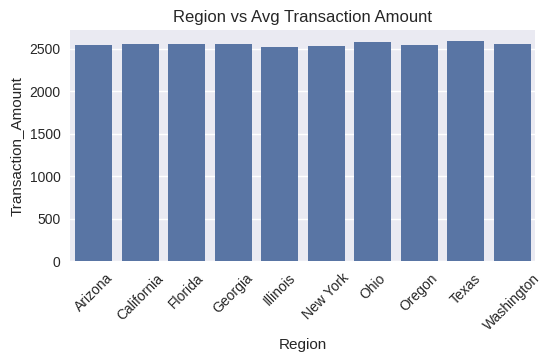

/tmp/ipython-input-2228132284.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Payment_Status',y='Credit_Utilization_%',palette='Blues')


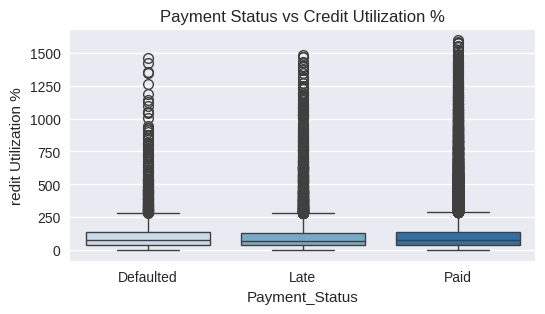

In [15]:
#Step 2: Bivariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns

#1. Transaction Amount vs Age
plt.figure(figsize=(6,3))
plt.hexbin(
    df['Age'],
    df['Transaction_Amount'],
    gridsize=40,
    cmap='Blues',
    extent=[df['Age'].min(), df['Age'].max(),
            df['Transaction_Amount'].min(), df['Transaction_Amount'].max()]
)
plt.colorbar(label='Count')
plt.show()

#2. Income Range vs Credit Utilization%
plt.figure(figsize=(6,3))
sns.boxplot(data=df,x='Income_Range',y='Credit_Utilization_%')
plt.title("Income Range vs Credit Utilization")
plt.show()

#3. Payment Status vs Transaction Amount
plt.figure(figsize=(6,3))
sns.boxplot(data=df,x='Payment_Status',y='Transaction_Amount')
plt.title("Payment Status vs Transaction Amount")
plt.show()

#4. Region vs Average Transaction Amount
region_spend=df.groupby('Region')['Transaction_Amount'].mean().reset_index()

plt.figure(figsize=(6,3))
sns.barplot(data=region_spend,x='Region',y='Transaction_Amount')
plt.title("Region vs Avg Transaction Amount")
plt.xticks(rotation=45)
plt.show()

#5. Payment Status vs Credit Utilization %
df['Credit_Utilization_%']=(df['Current_Balance']/df['Credit_Limit'])*100

plt.figure(figsize=(6,3))
sns.boxplot(data=df,x='Payment_Status',y='Credit_Utilization_%',palette='Blues')
plt.title("Payment Status vs Credit Utilization %")
plt.ylabel("redit Utilization %")
plt.show()



/tmp/ipython-input-32925826.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot=df.pivot_table(index='Region',columns='Payment_Status',values='Transaction_Amount',aggfunc='mean')


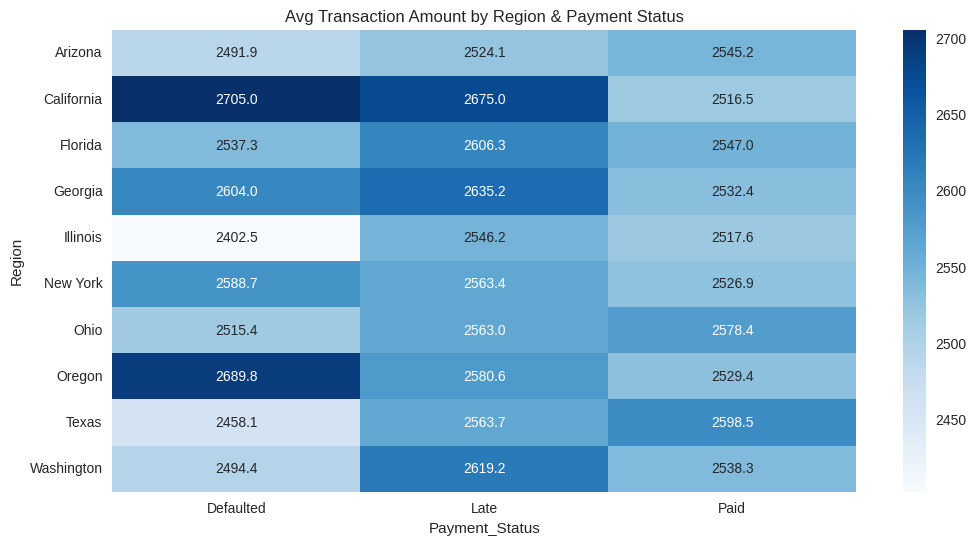

/tmp/ipython-input-32925826.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped=df.groupby(['Region','Income_Range'])['Credit_Utilization_%'].mean()


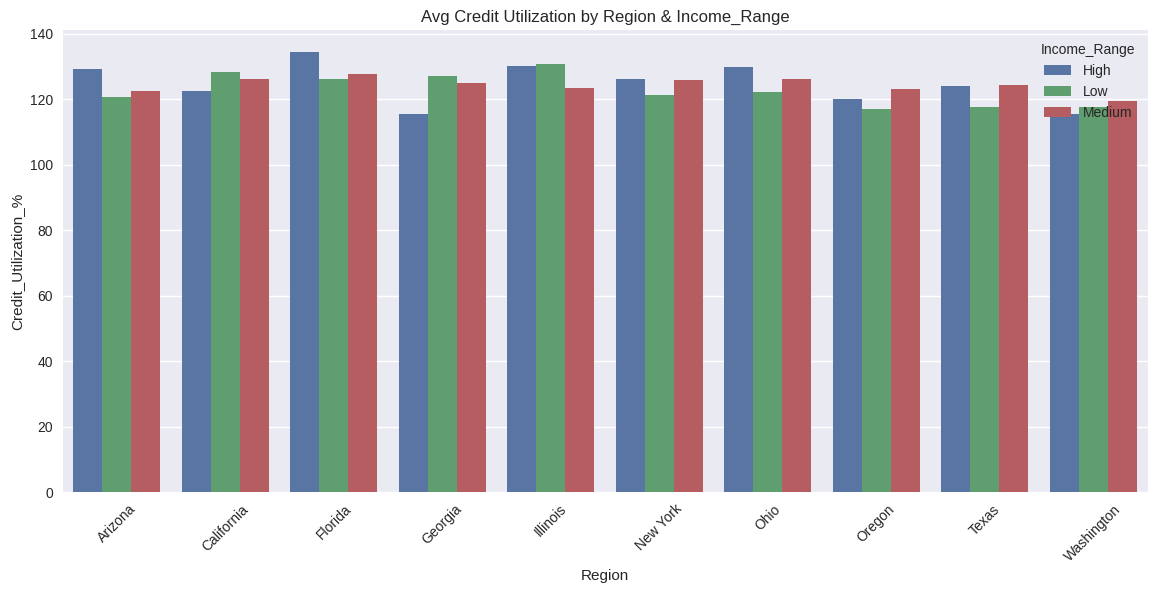

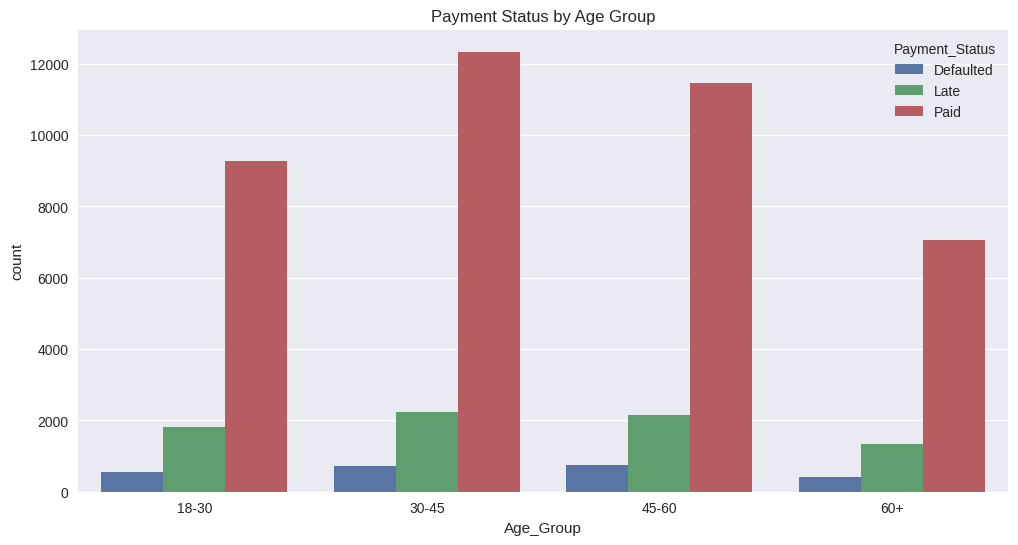

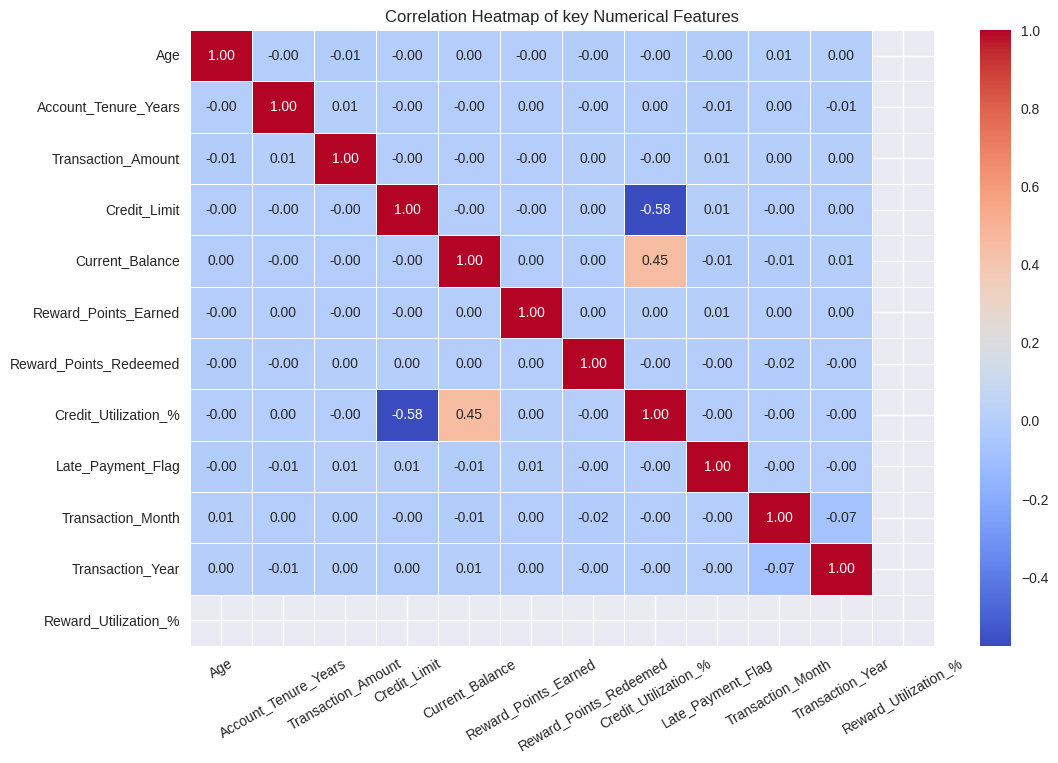

In [16]:
#Step 3: Multivariate Analysis

#1. Region + Merchant Category + Payment Status(Heatmap Table)

pivot=df.pivot_table(index='Region',columns='Payment_Status',values='Transaction_Amount',aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot,annot=True,fmt=".1f",cmap='Blues')
plt.title("Avg Transaction Amount by Region & Payment Status")
plt.show()

#2. Income Range + Region + Avg Credit Utilization % (Clustered Bar Chart)

grouped=df.groupby(['Region','Income_Range'])['Credit_Utilization_%'].mean()
grouped=grouped.reset_index()
plt.figure(figsize=(14,6))
sns.barplot(data=grouped,x='Region',y='Credit_Utilization_%',hue='Income_Range',)
plt.title("Avg Credit Utilization by Region & Income_Range")
plt.xticks(rotation=45)
plt.show()

#3. Age Group + Spending Category + Payment Behavior(Stacked Countplot)

df['Age_Group']=pd.cut(df['Age'],bins=[18,30,45,60,80],
labels=['18-30','30-45','45-60','60+'])

plt.figure(figsize=(12,6))
sns.countplot(data=df,x='Age_Group',hue='Payment_Status')
plt.title("Payment Status by Age Group")
plt.show()

#4. Correlation Heatmap

plt.figure(figsize=(12,8))

corr_matrix=df.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5,cbar=True)
plt.title("Correlation Heatmap of key Numerical Features")
plt.xticks(rotation=30)
plt.show()



/tmp/ipython-input-951598310.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Merchant_Category')['Transaction_Amount'].sum().sort_values(ascending=False).head(10).reset_index()
/tmp/ipython-input-951598310.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_merchants,x='Merchant_Category',y='Transaction_Amount',palette='Blues')


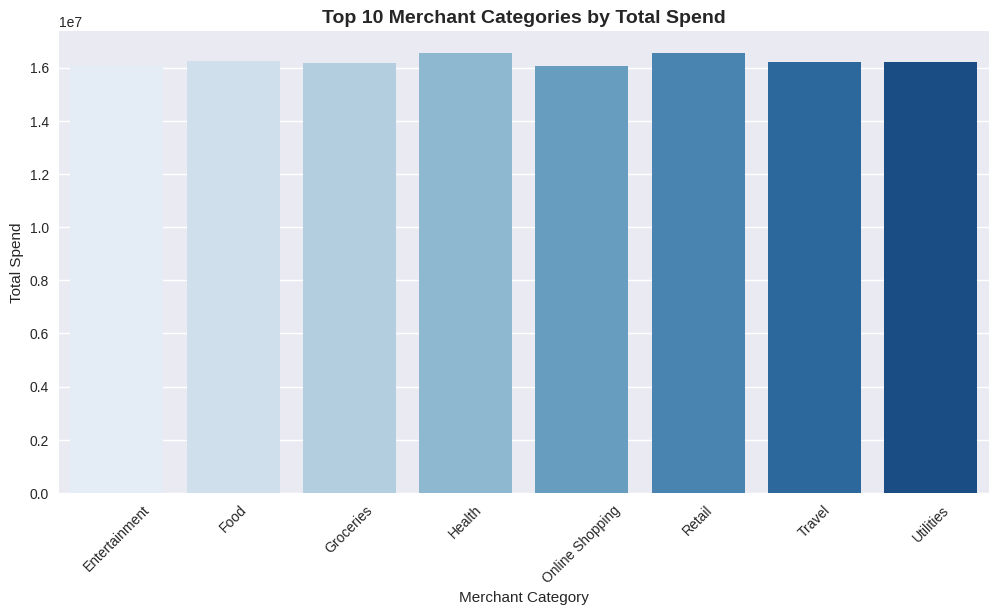

/tmp/ipython-input-951598310.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  util_by_income=(df.groupby('Income_Range')['Credit_Utilization_%'].mean().reset_index())
/tmp/ipython-input-951598310.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=util_by_income,x='Income_Range',y='Credit_Utilization_%',palette='Blues')


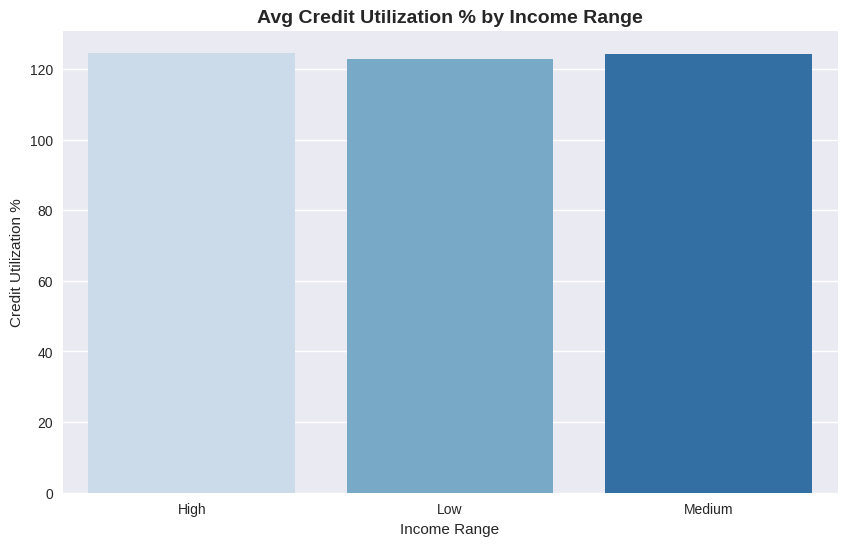

/tmp/ipython-input-951598310.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_region=(df.groupby(['Region','Payment_Status']).size().reset_index(name='Count'))


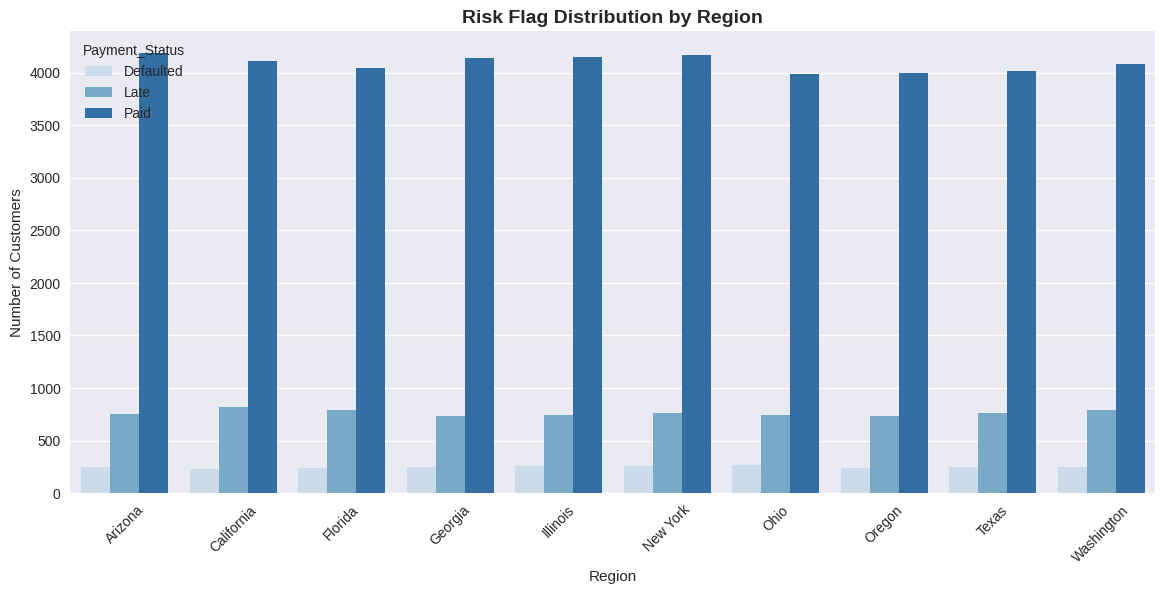

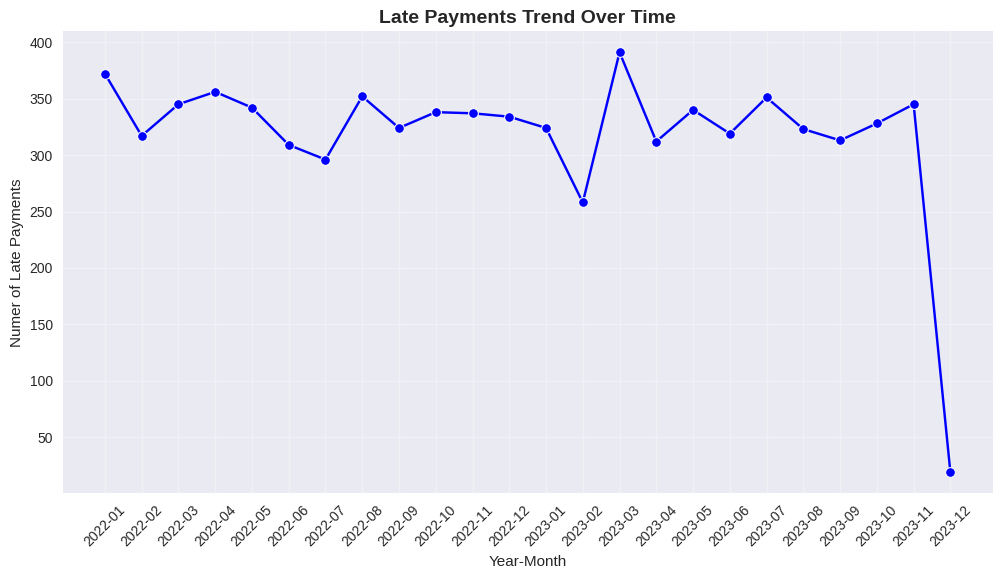

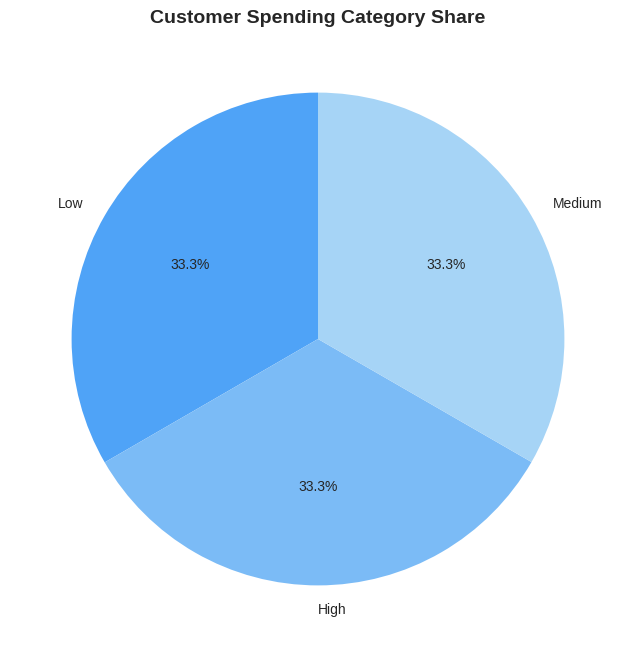

In [17]:
#PHASE 5 --> BUSINESS VISUALIZATION (Portfolio Charts)

#1. Top 10 Merchant Categories by Spend
top_merchants=(
df.groupby('Merchant_Category')['Transaction_Amount'].sum().sort_values(ascending=False).head(10).reset_index()
)
plt.figure(figsize=(12,6))
sns.barplot(data=top_merchants,x='Merchant_Category',y='Transaction_Amount',palette='Blues')
plt.title("Top 10 Merchant Categories by Total Spend",fontsize=14,fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Total Spend")
plt.xlabel("Merchant Category")
plt.show()

#2. Avg Credit Utilization % by Income Range
util_by_income=(df.groupby('Income_Range')['Credit_Utilization_%'].mean().reset_index())
plt.figure(figsize=(10,6))
sns.barplot(data=util_by_income,x='Income_Range',y='Credit_Utilization_%',palette='Blues')
plt.title("Avg Credit Utilization % by Income Range",fontsize=14,fontweight='bold')
plt.ylabel("Credit Utilization %")
plt.xlabel("Income Range")
plt.show()

#3. Risk Flag Distribution by Region
risk_by_region=(df.groupby(['Region','Payment_Status']).size().reset_index(name='Count'))
plt.figure(figsize=(14,6))
sns.barplot(data=risk_by_region,x='Region',y='Count',hue='Payment_Status',palette='Blues')
plt.title("Risk Flag Distribution by Region",fontsize=14,fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

#4. Late Payments Trend Over Time
df['Year_Month']=df['Transaction_Date'].dt.to_period('M').astype(str)

late_trend=(df[df['Payment_Status']=='Late'].groupby('Year_Month').size().reset_index(name='Late_Count'))
plt.figure(figsize=(12,6))
sns.lineplot(data=late_trend,x='Year_Month',y='Late_Count',marker='o',color='blue')
plt.title("Late Payments Trend Over Time",fontsize=14,fontweight='bold')
plt.xlabel("Year-Month")
plt.ylabel("Numer of Late Payments")
plt.xticks(rotation=45)
plt.grid(True,alpha=0.3)
plt.show()

#5. Customer Spending Category Share (Low /Medium /High)

spend_counts=df['Spending_Category'].value_counts().reset_index()
spend_counts.columns=['Spending_Category','Count']
plt.figure(figsize=(8,8))
plt.pie(spend_counts['Count'],labels=spend_counts['Spending_Category'],autopct='%1.1f%%',startangle=90,colors=['#4FA3F7','#7BBBF6','#A6D4F6'])
plt.title("Customer Spending Category Share",fontsize=14,fontweight='bold')
plt.show()






In [18]:
# 📌 Phase 6 — Insights & Business Findings

## 1. Customer Behavior Insights
#- Majority of customers are aged **30–56**, indicating a financially stable user base.
#- Spending is concentrated in **Groceries, Retail, Online Shopping, Restaurants, and Travel**.

## 2. Credit & Payment Behavior
#- **Low-income customers show the highest credit utilization**, increasing default risk.
#- Late payers consistently have **higher utilization** than on-time payers.
#- Many customers hit **100% utilization**, indicating over-leverage risk.

## 3. Regional Insights
#- Highest average spend observed in **New York, Texas, California, and Florida**.
#- Regions like **Florida and Texas** show higher late-payment counts, requiring targeted credit monitoring.

## 4. Spending Patterns
#- Median transaction amount is around **₹2,500–₹3,000**.
#- Customers are evenly distributed across **Low, Medium, and High** spending categories.

## 5. Payment Trend Insights
#- Late payments occur throughout the year with noticeable spikes, indicating periodic financial strain or seasonal expenses.

## 6. Correlation Highlights
#- **Credit Limit ↔ Current Balance:** Strong positive relationship.
#- **Credit Utilization ↔ Late Payment Flag:** Moderate positive correlation.
#- **Transaction Amount ↔ Reward Points:** Expected positive trend.

## 📌 Business Conclusion
#Customers with **high utilization, low income, and younger age groups (18–30)** show higher financial risk.
#High-spend categories like **Groceries, Retail, Travel, and Online Shopping** represent strong revenue channels.
#Regions with increasing late payments (Florida, Texas) should be monitored for early risk detection and customer engagement programs.


In [19]:
# 📦 Phase 7 — Final Deliverables
#
# This section summarizes all outputs created in the American Express Customer Analytics Project.
# These deliverables complete the end-to-end workflow from data ingestion to business insights.
#
# -----------------------------------------------------------
#
# ✔ 1. Cleaned Dataset
# File: Amex_Customer_Transactions_Cleaned.csv
# Contains fully cleaned, imputed, standardized, and feature-engineered data:
# - Missing values handled
# - Outliers capped
# - Datatypes fixed
# - New features added (Credit Utilization %, Late Payment Flag, Age Group, etc.)
#
# -----------------------------------------------------------
#
# ✔ 2. Full Project Notebook
# File: Amex_Analytics_Report.ipynb
# Includes the complete pipeline:
# - Phase 1: Initialization
# - Phase 2: Data Cleaning
# - Phase 3: Feature Engineering
# - Phase 4: EDA (Univariate, Bivariate, Multivariate)
# - Phase 5: Business Visualizations
# - Phase 6: Insights
#
# -----------------------------------------------------------
#
# ✔ 3. Business Visualization Outputs
# High-quality charts generated in the notebook:
# - Top 10 Merchant Categories by Spend
# - Avg Credit Utilization % by Income Range
# - Risk / Payment Status Distribution by Region
# - Late Payment Trend Over Time
# - Spending Category Share (Low/Medium/High)
# - Multivariate heatmaps and grouped bar charts
#
# -----------------------------------------------------------
#
# ✔ 4. Insights Summary
# (Already added in Phase 6)
# Contains final business conclusions:
# - Spending behavior
# - Risk behavior
# - Regional performance
# - Payment trends
# - Customer segmentation insights
#
# -----------------------------------------------------------
#
# ✔ 5. Reproducibility Guide
# Steps for rerunning this project:
# 1. Install required Python libraries:
#       pip install pandas numpy matplotlib seaborn plotly
#
# 2. Load Amex_Proj_data.txt or the cleaned CSV.
#
# 3. Run the notebook from top to bottom.
#
# 4. Visual outputs will render automatically.
#
# -----------------------------------------------------------
#
# ✔ 6. Optional Dashboards (if added later)
# - Power BI Dashboard: Customer Spend & Risk Overview
# - Tableau Dashboard: Regional Spend & Payment Behavior
#
# These can be created using the cleaned dataset for extra portfolio strength.
#
# -----------------------------------------------------------
#
# 🎯 Project Completion Note
# This project demonstrates:
# - End-to-end data cleaning
# - Feature engineering
# - Deep exploratory analysis
# - Business storytelling
# - Portfolio-ready charts and insights
#
# The project is now ready for GitHub, LinkedIn, and portfolio use.


In [20]:
# Save cleaned dataset to CSV
df.to_csv("Amex_Customer_Transactions_Cleaned.csv", index=False)

print("Cleaned dataset saved as: Amex_Customer_Transactions_Cleaned.csv")


Cleaned dataset saved as: Amex_Customer_Transactions_Cleaned.csv
